In [1]:
import sys
import os
import copy

# Compute absolute path to the src/ folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_path = os.path.join(project_root, "src")

# Add src/ to sys.path
sys.path.insert(0, src_path)

# Now you can import the code
from qvarnet.hamiltonians import HarmonicOscillator
from qvarnet.samplersv2 import MetropolisHastingsSampler


import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


 L box: 20.0 

Number of samples: 1000000


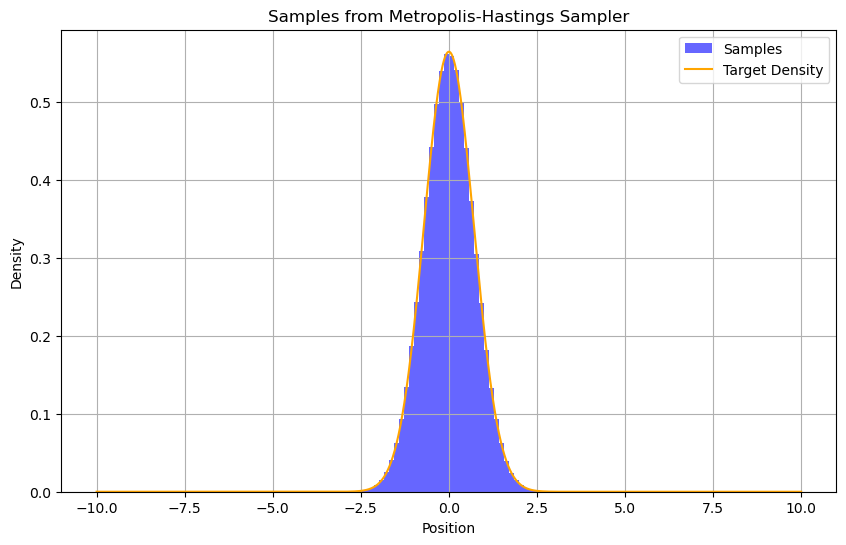

In [15]:
# test sampler

#----------------------- DEFINE PARAMETERS -----------------------
EPOCHS             = 1
N_SAMPLES          = 1000_000
L_BOX              = 20.0
STEP_SIZE          = 0.1
BURN_IN            = 500

class MockModel(nn.Module):
    def __init__(self):
        super(MockModel, self).__init__()
    
    def forward(self, x):
        return torch.exp(-0.5 * x**2)  # Gaussian wave function
    
model = MockModel().to(device)

#----------------------- DEFINE SAMPLER -----------------------
sampler = MetropolisHastingsSampler(
    model     = model,
    n_samples = N_SAMPLES,
    step_size = STEP_SIZE,
    burn_in   = BURN_IN,
    is_wf     = True,
    L_BOX     = L_BOX,
)

sampler.to(device)
#----------------------- RUN SAMPLER -----------------------

x0 = torch.tensor([0.0], device=device)  # Initial point for the sampler
samples = sampler(x0, method="parallel", n_walkers=(N_SAMPLES)).requires_grad_(True)

#----------------------- PLOT SAMPLES -----------------------
plt.figure(figsize=(10, 6))
print(f"Number of samples: {samples.shape[0]}")
plt.hist(samples.detach().cpu().numpy(), bins=50, density=True, alpha=0.6, color='blue', label='Samples')
x = torch.linspace(-L_BOX/2, L_BOX/2, 10000).to(device)
y = model(x).pow(2) / (torch.trapz(model(x).pow(2), x))
plt.plot(x.cpu().numpy(), y.detach().cpu().numpy(), color='orange', label='Target Density')
plt.title('Samples from Metropolis-Hastings Sampler')
plt.xlabel('Position')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

Parameter a:
 0.5
 L box: 20.0 



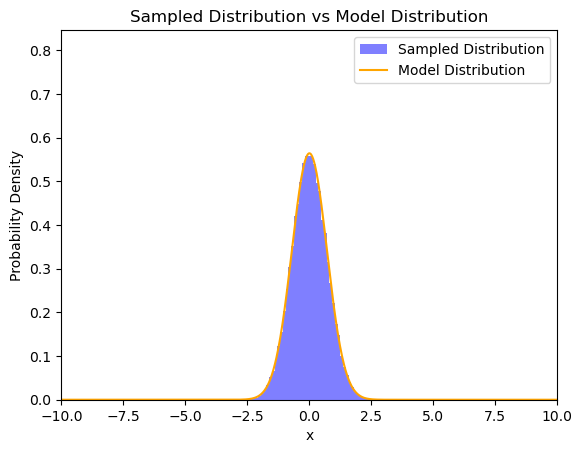

TEST---------------------
VMC gradient: -2.9802322387695312e-08
Analytic gradient: 0.0
STOP TEST


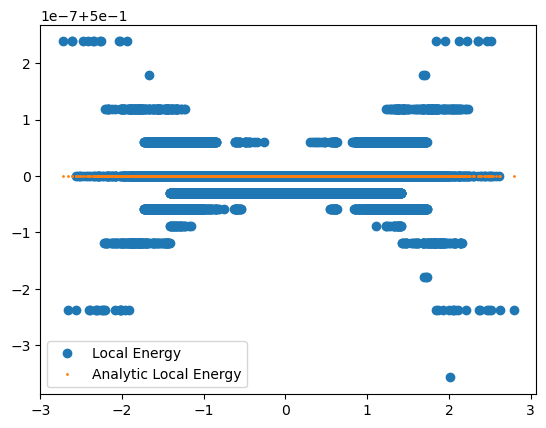

A = 0.5
energy: 0.5
loss_only_kin: 0.25013506412506104

analytic energy LOCAL: 0.5
analytic energy: 0.5
no way this is real: 0.5
GRADIENTS---------------------------------
 analytic gradient:0.0
 model.a.grad: 0.0005405544652603567
 model_kin.a.grad: 0.0005405544652603567
Optimizer state: {'state': {}, 'param_groups': [{'lr': 1e-05, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0]}]}
Optimizer param groups: [{'params': [Parameter containing:
tensor(0.5000, device='cuda:0', requires_grad=True)], 'lr': 1e-05, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False}]
Optimizer state: defaultdict(<class 'dict'>, {})
Optimizer state: defaultdict(<class 'dict'>, {Parameter containi

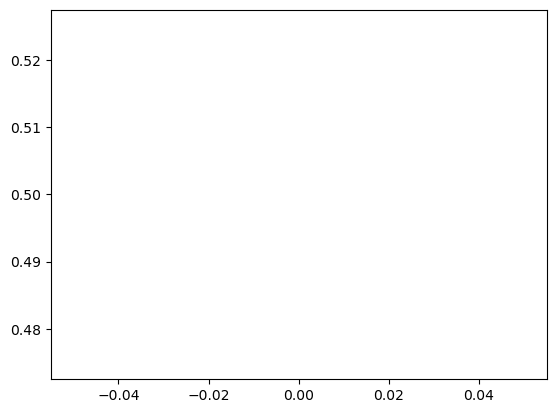

In [19]:
import time
from tqdm import tqdm
from torchviz import make_dot
import numpy as np


#----------------------- DEFINE PARAMETERS -----------------------
EPOCHS             = 1
N_SAMPLES          = 50_000
L_BOX              = 20.0
STEP_SIZE          = 0.1
BURN_IN            = 2000
CALLBACK_PATIENCE  = 10000
CALLBACK_MIN_DELTA = 1e-5
LEARNING_RATE      = 1e-5
MLP_LAYER_DIMS     = [1, 10, 1]
DEBUG              = False
AA                 = 0.5

wf_history      = []
samples_history = []
energy_history  = []

local_energy_history = []
samples_history = []
dict_state_history = []

#----------------------- DEFINE MODEL TOPOLOGY -----------------------
class StupidAnsatz(nn.Module):
    def __init__(self, a):
        super(StupidAnsatz, self).__init__()
        self.a = torch.nn.Parameter(torch.tensor(a, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        return torch.exp(-self.a * x**2)
model = StupidAnsatz(a=AA)  # Initialize with a small value for a
model.to(device)
model.a.grad = None  # Reset gradients to None before training

model_kin = copy.deepcopy(model)  # Create a copy of the model for kinetic energy calculations

#------------------------ DEFINE HAMILTONIAN -----------------------
class KmodHO(HarmonicOscillator):
    def kinetic_local_energy(self, x):
        dpsi_dx = torch.autograd.grad(self.model(x), x, create_graph=True, grad_outputs=torch.ones_like(self.model(x)))[0]
        d2psi_dx2 = torch.autograd.grad(dpsi_dx, x, create_graph=True, grad_outputs=torch.ones_like(dpsi_dx))[0]
        return -0.5 * d2psi_dx2 / self.model(x)
hamiltonian = KmodHO(model=model)
hamiltonian.to(device)

class NewHami(nn.Module):
    def __init__(self, model):
        super(NewHami, self).__init__()
        self.model = model

    def kinetic_local_energy(self, x):
        psi = self.model(x)
        dpsi_dx = torch.autograd.grad(psi, x, create_graph=True, grad_outputs=torch.ones_like(psi))[0]
        d2psi_dx2 = torch.autograd.grad(dpsi_dx, x, create_graph=True, grad_outputs=torch.ones_like(dpsi_dx))[0]
        kinetic_energy = -0.5 * d2psi_dx2 / psi
        return kinetic_energy

    def forward(self, x):
        kinetic_energy = self.kinetic_local_energy(x)
        potential_energy = 0.5 * x**2
        return kinetic_energy + potential_energy
    
hamiltonian = NewHami(model=model)
hamiltonian.to(device)
hami2 = NewHami(model=model_kin)  # Create a second Hamiltonian for kinetic energy calculations
hami2.to(device)

#------------------------ DEFINE SAMPLER -----------------------
sampler = MetropolisHastingsSampler(
    model     = model,
    n_samples = N_SAMPLES,
    step_size = STEP_SIZE,
    burn_in   = BURN_IN,
    is_wf     = True,
    L_BOX     = L_BOX,
)
sampler.to(device)

# callback = EarlyStoppingCallback(patience=CALLBACK_PATIENCE, min_delta=CALLBACK_MIN_DELTA)
callback = None  # Disable early stopping for now

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for name, param in model.named_parameters():
    if param is not None:
        print(f"Parameter {name}:\n {param.data.cpu().numpy() if param is not None else None}")

sampling_times = []
energy_times = []

def analytic_local_energy(x, a):
    # return 0.5*x**2 + a * (1 - 2 * a * x**2)
    return a + x**2 * (0.5 - 2 * a**2)  # Corrected analytic local energy formula

def analytic_energy(a):
    x = torch.linspace(-L_BOX, L_BOX, N_SAMPLES, device=device)
    psi = model(x)
    psi_squared = psi.pow(2)
    norm = torch.trapz(psi_squared, x)
    integral = torch.trapz(psi_squared * analytic_local_energy(x, a), x)
    return integral / norm

def is_this_real(a):
    return 0.125/a + 0.5*a

def analytic_gradient(a):
    # Analytic gradient of the energy with respect to the parameter a
    return 0.5 - 0.125 / a**2

x_plotting = torch.linspace(-L_BOX/2, L_BOX/2, 1000).to(device)

for epoch in (range(EPOCHS)):
    optimizer.zero_grad()
    
    # x0 = torch.randn(1, device=device)
    start_sample_time = time.time()
    # Run sampler
    sampler.model = model
    x0 = torch.tensor([0.0], device=device)  # Initial point for the sampler
    samples = sampler(x0, method="parallel", n_walkers=(N_SAMPLES)).requires_grad_(True)
    end_sample_time = time.time()
    plt.hist(samples.cpu().detach().numpy(), bins=50, density=True, alpha=0.5, color='blue', label='Sampled Distribution')
    y = model(x_plotting).pow(2) / (torch.trapz(model(x_plotting).pow(2), x_plotting))
    plt.plot(x_plotting.cpu().numpy(), y.cpu().detach().numpy(), color='orange', label='Model Distribution')
    plt.xlim(-L_BOX/2, L_BOX/2)
    plt.ylim(0, 1.5 * y.max().item())
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.title('Sampled Distribution vs Model Distribution')
    plt.legend()
    plt.show()
    
    # Compute the mean and std of the local energy
    start_energy_time = time.time()
    hamiltonian.model = model
    local_energy = hamiltonian(samples)
    squared_psi = model(samples).pow(2)
    sampled_norm = torch.mean(squared_psi)
    end_energy_time = time.time()

    only_kin_energy = hami2.kinetic_local_energy(samples)
    loss_only_kin = only_kin_energy.mean()
    loss = local_energy.mean()

        # After computing local_energy
    log_psi = torch.log(model_kin(samples))
    O_a = torch.autograd.grad(log_psi.sum(), model_kin.a, create_graph=True)[0] / len(samples)

    E_mean = local_energy.mean()
    O_mean = O_a.mean()

    # Proper VMC energy gradient
    vmc_energy_gradient = 2 * (torch.mean(local_energy * O_a) - E_mean * O_mean)
    print(f"TEST---------------------")
    print(f"VMC gradient: {vmc_energy_gradient.item()}")
    print(f"Analytic gradient: {analytic_gradient(model.a.item())}")
    print(f"STOP TEST")

    # Compute gradients
    loss.backward()
    loss_only_kin.backward()
    
    plt.plot(samples.cpu().detach().numpy(), local_energy.cpu().detach().numpy(),'o' ,label='Local Energy')
    analytic_local_energy_values = analytic_local_energy(samples, model.a)
    plt.plot(samples.cpu().detach().numpy(), analytic_local_energy_values.cpu().detach().numpy(),'o', label='Analytic Local Energy', markersize=1)
    plt.legend()
    plt.show()

    print(f"A = {model.a.item()}")
    print(f"energy: {loss.item()}")
    print(f"loss_only_kin: {loss_only_kin.item()}")
    print(f"")
    print(f"analytic energy LOCAL: {analytic_local_energy(samples, model.a).mean().item()}")
    print(f"analytic energy: {analytic_energy(model.a).item()}")
    print(f"no way this is real: {is_this_real(model.a.item())}")
    print(f"GRADIENTS---------------------------------")
    print(f" analytic gradient:{analytic_gradient(model.a.item())}")
    print(f" model.a.grad: {model.a.grad.item()}")
    print(f" model_kin.a.grad: {model_kin.a.grad.item()}")

    dot = make_dot(loss, params=dict(model.named_parameters()))
    dot.render(f"computation_graph_epoch_{epoch}", format="png")  # Save

    sampling_times.append(end_sample_time - start_sample_time)
    samples_history.append(samples.cpu().detach())
    dict_state_history.append(model.state_dict())
    wf_history.append(model.state_dict())
    samples_history.append(samples)
    energy_history.append(loss.item())
    local_energy_history.append(local_energy.cpu().detach())
    energy_times.append(end_energy_time - start_energy_time)

    # check how optimizer is doing
    print(f"Optimizer state: {optimizer.state_dict()}")
    print(f"Optimizer param groups: {optimizer.param_groups}")
    print(f"Optimizer state: {optimizer.state}")


    optimizer.step()
    print(f"Optimizer state: {optimizer.state}")

    sampler.reset_statistics()

print("Ended training.")
plt.plot(energy_history, label='Energy History')

# Test the whole software with a stupid function

$V(x) = \frac12 x^2$:

$$\phi_\alpha(x) = e^{-\alpha x^2}$$

$$E_{loc}^\alpha = -\frac{1}{2}2\alpha(2\alpha x^2-1) + \frac12 x^2 = \dots = \alpha + x ^2\bigg(\frac12-2\alpha^2\bigg)=0.5 x^2+a (1.-2. a x^2) $$

$$\partial_a E_{loc} = (1-2\alpha x^2)+\alpha(-2x^2) = 1-4\alpha x^2$$

$$E = \int \phi_a(x)^2\bigg\{0.5 x^2+a(1-2ax^2)\bigg\}\; dx=\frac{1}{8a}+\frac12 a$$

Analytic computation of the gradient of the whole energy:

$$\partial_a E = 0.5-\frac{0.125}{a^2}$$

> Using that $E=\int_{-\infty}^{\infty} \phi_\alpha(x)^2 E_{loc}^\alpha(x) dx$, we can decompose the gradient as follows:

$$\partial_a E = \int_{-\infty}^{\infty}dx\bigg\{\partial_a(\phi_\alpha(x)^2)E_{loc}^\alpha+\phi_\alpha(x)^2\partial_a(E_{loc}^a)\bigg\}$$

Let's split the integral:


$$\partial_a E = \int_{-\infty}^{\infty}dx\partial_a(\phi_\alpha(x)^2)E_{loc}^\alpha+\int_{-\infty}^{\infty}dx\phi_\alpha(x)^2\partial_a(E_{loc}^a)$$

So we can compute the second term analytically:

$$\int_{-\infty}^{\infty}dx\phi_\alpha(x)^2\partial_a(E_{loc}^a)=\int_{-\infty}^{\infty}dx \phi_\alpha(x)^2  (1-4\alpha x^2) \approx \frac{1}{N}\sum_{x_i\sim\phi_\alpha(x)^2} \partial_a E_{loc}^a = \frac{1}{N}\sum_{x_i\sim\phi_\alpha(x)^2}  (1-4\alpha x_i^2)  =  \partial_a E_{approx}$$

In [40]:
import time
from tqdm import tqdm
from torchviz import make_dot
import numpy as np


#----------------------- DEFINE PARAMETERS -----------------------
EPOCHS             = 1
N_SAMPLES          = 10_000_000
L_BOX              = 20.0
STEP_SIZE          = 0.1
BURN_IN            = 200
CALLBACK_PATIENCE  = 10000
CALLBACK_MIN_DELTA = 1e-5
LEARNING_RATE      = 1e-5
MLP_LAYER_DIMS     = [1, 10, 1]
DEBUG              = False
AA                 = 0.2

wf_history      = []
samples_history = []
energy_history  = []

local_energy_history = []
samples_history = []
dict_state_history = []

#----------------------- DEFINE MODEL TOPOLOGY -----------------------
class StupidAnsatz(nn.Module):
    def __init__(self, a):
        super(StupidAnsatz, self).__init__()
        self.a = torch.nn.Parameter(torch.tensor(a, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        return torch.exp(-self.a * x**2)
model = StupidAnsatz(a=AA)  # Initialize with a small value for a
model.to(device)
model.a.grad = None  # Reset gradients to None before training

#------------------------ DEFINE HAMILTONIAN -----------------------
class KmodHO(HarmonicOscillator):
    def kinetic_local_energy(self, x):
        dpsi_dx = torch.autograd.grad(self.model(x), x, create_graph=True, grad_outputs=torch.ones_like(self.model(x)))[0]
        d2psi_dx2 = torch.autograd.grad(dpsi_dx, x, create_graph=True, grad_outputs=torch.ones_like(dpsi_dx))[0]
        return -0.5 * d2psi_dx2 / self.model(x)
hamiltonian = KmodHO(model=model)
hamiltonian.to(device)


#------------------------ DEFINE SAMPLER -----------------------
sampler = MetropolisHastingsSampler(
    model     = model,
    n_samples = N_SAMPLES,
    step_size = STEP_SIZE,
    burn_in   = BURN_IN,
    is_wf     = True,
    L_BOX     = L_BOX,
)
sampler.to(device)

# callback = EarlyStoppingCallback(patience=CALLBACK_PATIENCE, min_delta=CALLBACK_MIN_DELTA)
callback = None  # Disable early stopping for now

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for name, param in model.named_parameters():
    if param is not None:
        print(f"Parameter {name}:\n {param.data.cpu().numpy() if param is not None else None}")

sampling_times = []
energy_times = []

def analytic_local_energy(x, a):
    # return 0.5*x**2 + a * (1 - 2 * a * x**2)
    return a + x**2 * (0.5 - 2 * a**2)  # Corrected analytic local energy formula

def analytic_energy(a):
    x = torch.linspace(-L_BOX, L_BOX, N_SAMPLES, device=device)
    psi = model(x)
    psi_squared = psi.pow(2)
    norm = torch.trapz(psi_squared, x)
    integral = torch.trapz(psi_squared * analytic_local_energy(x, a), x)
    return integral / norm

def is_this_real(a):
    return 0.125/a + 0.5*a

def analytic_gradient(a):
    # Analytic gradient of the energy with respect to the parameter a
    return 0.5 - 0.125 / a**2

x_plotting = torch.linspace(-L_BOX/2, L_BOX/2, 1000).to(device)

for epoch in (range(EPOCHS)):
    optimizer.zero_grad()
    
    # x0 = torch.randn(1, device=device)
    start_sample_time = time.time()
    # Run sampler
    sampler.model = model
    x0 = torch.tensor([0.0], device=device)  # Initial point for the sampler
    samples = sampler(x0, method="parallel", n_walkers=(N_SAMPLES)).requires_grad_(True)
    end_sample_time = time.time()
    
    # Compute the mean and std of the local energy
    start_energy_time = time.time()
    hamiltonian.model = model
    local_energy = hamiltonian(samples)
    end_energy_time = time.time()

    loss = local_energy.mean()

    # Compute gradients
    loss.backward()
    grad_importance = torch.mean((1-4*model.a*samples**2))
    print(f"Gradient importance: {grad_importance.item():.6e}")
    print(f"gradient with backpropagation: {model.a.grad.item():.6e}")
    print(f"Difference between backward and one term gradient: {torch.abs(model.a.grad - grad_importance).item():.2e}")
    print(f"actual gradient: {0.5 - 0.125 / model.a.item()**2:.6e}")

    sampling_times.append(end_sample_time - start_sample_time)
    samples_history.append(samples.cpu().detach())
    dict_state_history.append(model.state_dict())
    wf_history.append(model.state_dict())
    samples_history.append(samples)
    energy_history.append(loss.item())
    local_energy_history.append(local_energy.cpu().detach())
    energy_times.append(end_energy_time - start_energy_time)


    optimizer.step()

    sampler.reset_statistics()

print("Ended training.")

Parameter a:
 0.20000000298023224
 L box: 20.0 

Gradient importance: 1.799181e-05
gradient with backpropagation: 1.823902e-05
Difference between backward and one term gradient: 2.47e-07
actual gradient: -2.625000e+00
Ended training.
